In [1]:
import os
import pandas as pd
import numpy as np

import eppy
from eppy import modeleditor
from geomeppy import IDF


In [2]:
tabula_data = pd.read_excel('tabula-calculator.xlsx', sheet_name="Calc.Set.Building")

In [3]:
IDF.setiddname('/Applications/EnergyPlus-22-1-0/Energy+.idd')
idf = IDF('/Applications/EnergyPlus-22-1-0/ExampleFiles/Minimal.idf')
idf.epw = "USA_CO_Golden-NREL.724666_TMY3.epw"

In [4]:
class archetype(object): 
    
    def __init__(self, data):
        
        """Init function. Assign the input data to the instance of the object."""
        
        self.data = data
    
    def calculate_wall_length(self,floor_area):
        return np.sqrt(floor_area)


    def get_geometries(self):
        
        n_storey = self.data['n_Storey']
        
        n_floor = n_storey + 1
        a_floor = self.data['A_Floor_1']
        
        n_wall = 4        
        l_wall = self.calculate_wall_length(a_floor)
        a_wall = self.data['A_Wall_1']
        
        h_ceiling = 2.5 #tabula_data['h_Ceiling'][index]

        a_window = self.data['A_Window_1']
        a_window_N = self.data['A_Window_North']
        a_window_S = self.data['A_Window_South']
        a_window_E = self.data['A_Window_East']
        a_window_W = self.data['A_Window_West']
        
        roof_inclination = self.data['Code_RoofType']
        
        return [n_storey, n_floor, a_floor, n_wall, l_wall, h_ceiling,
                a_window,a_window_N, a_window_E, a_window_S, a_window_W, 
                a_wall, roof_inclination]
        
    def add_roof(self):
        
        geometry = self.get_geometries()
        
        l_wall = geometry[4]
        a_wall = geometry[11]
        n_storey = geometry[0]
        h_ceiling = geometry[5]
        a_window = geometry[6]
        a_window_N = geometry[7]
        a_window_E = geometry[8]
        a_window_S = geometry[9]
        a_window_W = geometry[10]
        roof_inclination = geometry[12]
        
        roof_coords = self.get_roof_coords(roof_inclination,l_wall,n_storey,h_ceiling)
        
        roof_2_2 = idf.newidfobject(
            'BUILDINGSURFACE:DETAILED',
            Name='roof_2_2', 
            Construction_Name = "Project Flat Roof",
            Surface_Type = 'roof',
            Zone_Name='Block Living Storey 1')
        
        for index, roof in enumerate(idf.getsurfaces("roof")):
            roof.Vertex_1_Xcoordinate = roof_coords[index][0][0]
            roof.Vertex_1_Ycoordinate = roof_coords[index][0][1]
            roof.Vertex_1_Zcoordinate = roof_coords[index][0][2]
            roof.Vertex_2_Xcoordinate = roof_coords[index][1][0]
            roof.Vertex_2_Ycoordinate = roof_coords[index][1][1]
            roof.Vertex_2_Zcoordinate = roof_coords[index][1][2]
            roof.Vertex_3_Xcoordinate = roof_coords[index][2][0]
            roof.Vertex_3_Ycoordinate = roof_coords[index][2][1]
            roof.Vertex_3_Zcoordinate = roof_coords[index][2][2]
            roof.Vertex_4_Xcoordinate = roof_coords[index][3][0]
            roof.Vertex_4_Ycoordinate = roof_coords[index][3][1]
            roof.Vertex_4_Zcoordinate = roof_coords[index][3][2]

    
    def get_roof_coords(self,inclination, l_wall, n_storey, h_ceiling):
        """Assumes Roof height is 1.5 m"""
        
        roof_coords = [[[l_wall,0,n_storey*h_ceiling],
                       [l_wall,l_wall/2,n_storey*h_ceiling+1.5],
                       [0,l_wall/2,n_storey*h_ceiling+1.5],
                       [0,0,n_storey*h_ceiling]],
                      [[l_wall,l_wall,n_storey*h_ceiling],
                       [l_wall,l_wall/2,n_storey*h_ceiling+1.5],
                       [0,l_wall/2,n_storey*h_ceiling+1.5],
                       [0,l_wall,n_storey*h_ceiling]]]
        
        return roof_coords
    
    def build(self):
        
        geometry = self.get_geometries()
        
        l_wall = geometry[4]
        a_wall = geometry[11]
        n_storey = geometry[0]
        h_ceiling = geometry[5]
        a_window = geometry[6]
        a_window_N = geometry[7]
        a_window_E = geometry[8]
        a_window_S = geometry[9]
        a_window_W = geometry[10]
        roof_inclination = geometry[12]
        
        idf.add_block(name='Living',
                      coordinates=[(l_wall,0),(l_wall,l_wall),(0,l_wall),(0,0)],
                      height=n_storey*h_ceiling,
                      num_stories = n_storey)
        
        idf.set_default_constructions()
        
        self.add_roof()
            
        idf.intersect_match()
        #idf.set_wwr(wwr=a_window/a_wall)
        idf.set_wwr(wwr=a_window/a_wall, wwr_map={0: a_window_N/a_window,
                                    90: a_window_E/a_window, 
                                    180: a_window_S/a_window,
                                    270: a_window_W/a_window},
                   construction="Project External Window")

        
        

        
        
        


In [5]:
b = archetype(data=tabula_data.iloc[1047])

In [6]:
b=b.build()

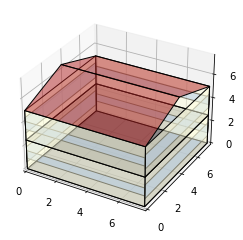

In [7]:
idf.view_model()

In [8]:
surfaces = idf.idfobjects['BUILDINGSURFACE:DETAILED']
surfaces

[
BUILDINGSURFACE:DETAILED,
    Block Living Storey 0 Wall 0001,    !- Name
    wall,                     !- Surface Type
    Project Partition,        !- Construction Name
    Block Living Storey 0,    !- Zone Name
    ,                         !- Space Name
    outdoors,                 !- Outside Boundary Condition
    ,                         !- Outside Boundary Condition Object
    SunExposed,               !- Sun Exposure
    WindExposed,              !- Wind Exposure
    autocalculate,            !- View Factor to Ground
    autocalculate,            !- Number of Vertices
    7.506663706334526,        !- Vertex 1 Xcoordinate
    0,                        !- Vertex 1 Ycoordinate
    2.5,                      !- Vertex 1 Zcoordinate
    7.506663706334526,        !- Vertex 2 Xcoordinate
    0,                        !- Vertex 2 Ycoordinate
    0,                        !- Vertex 2 Zcoordinate
    7.506663706334526,        !- Vertex 3 Xcoordinate
    7.506663706334526,        !- Ve

In [9]:
idf.run()


/Applications/EnergyPlus-22-1-0/energyplus --weather /Applications/EnergyPlus-22-1-0/WeatherData/USA_CO_Golden-NREL.724666_TMY3.epw --output-directory /Users/JackLynch/OneDrive - University of Cambridge/1. Cambridge/1. PhD/geomvTutorial --idd /Applications/EnergyPlus-22-1-0/Energy+.idd /Users/JackLynch/OneDrive - University of Cambridge/1. Cambridge/1. PhD/geomvTutorial/in.idf

EnergyPlus Starting
EnergyPlus, Version 22.1.0-ed759b17ee, YMD=2022.09.09 19:49
Adjusting Air System Sizing
Adjusting Standard 62.1 Ventilation Sizing
Initializing Simulation
Reporting Surfaces
Beginning Primary Simulation
Initializing New Environment Parameters
Warming up {1}
Warming up {2}
Warming up {3}
Warming up {4}
Warming up {5}
Warming up {6}
Starting Simulation at 12/21 for DENVER_STAPLETON ANN HTG 99.6% CONDNS DB
Initializing New Environment Parameters
Warming up {1}
Warming up {2}
Warming up {3}
Warming up {4}
Warming up {5}
Warming up {6}
Starting Simulation at 07/21 for DENVER_STAPLETON ANN CLG .4%

EnergyPlus Completed Successfully.


In [ ]:
roof_1_2.setcoords([(l_wall,0,n_floors*h_ceiling),
#                    (l_wall,l_wall/2,n_floors*h_ceiling+1.5),
#                    (0,l_wall/2,n_floors*h_ceiling+1.5),
#                    (0,0,n_floors*h_ceiling)])

In [20]:
roof_coords = [[7.5,0,5],
               [7.5,3.75,6.5],
               [0,3.75,6.5],
               [0,0,5]]
        

In [28]:
l_wall = 7.5
n_storey = 2
h_ceiling = 2.5

In [29]:
roof_coords = [[[l_wall,0,n_storey*h_ceiling],
                       [l_wall,l_wall/2,n_storey*h_ceiling+1.5],
                       [0,l_wall/2,n_storey*h_ceiling+1.5],
                       [0,0,n_storey*h_ceiling]],
                      [[l_wall,l_wall,n_storey*h_ceiling],
                       [l_wall,l_wall/2,n_storey*h_ceiling+1.5],
                       [0,l_wall/2,n_storey*h_ceiling+1.5],
                       [0,l_wall,n_storey*h_ceiling]]]

In [32]:
roof_coords[0][0][0]

7.5